<a href="https://colab.research.google.com/github/KanujanS/Suitable-Technology-Stacks/blob/main/Research_data_preprocessing_v3_data_balaced.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 1 ─ Imports
# ══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib, os, warnings

from sklearn.preprocessing        import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection      import train_test_split
from sklearn.utils                import resample

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi"      : 130,
    "axes.spines.top" : False,
    "axes.spines.right": False,
    "font.family"     : "DejaVu Sans",
    "axes.titlesize"  : 11,
    "axes.titleweight": "bold",
})
print("✓ All libraries imported")

✓ All libraries imported


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 2 ─ Upload & load dataset
# ══════════════════════════════════════════════════════════════
from google.colab import files

print("Upload your file: github_projects_cleaned.xlsx")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

df_raw = pd.read_excel(filename)
ORIGINAL_COUNT = len(df_raw)

print(f"\n✓ Loaded  : {ORIGINAL_COUNT:,} rows × {len(df_raw.columns)} columns")
print(f"  Columns : {list(df_raw.columns)}")

Upload your file: github_projects_cleaned.xlsx


Saving github_projects_cleaned.xlsx to github_projects_cleaned.xlsx

✓ Loaded  : 4,437 rows × 19 columns
  Columns : ['Project_ID', 'Project_Name', 'Domain', 'Project_Description', 'Functional_Requirements', 'Non_Functional_Requirements', 'Project_Size', 'Team_Size', 'Budget_Level', 'Duration_Months', 'Deployment', 'Frontend_Tech', 'Backend_Tech', 'Database', 'Source', 'GitHub_URL', 'Stars', 'Forks', 'Primary_Language']


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 3 ─ Step 1: Select ML-relevant columns
# ══════════════════════════════════════════════════════════════
FEATURE_COLS = [
    "Domain",                        # categorical → one-hot
    "Functional_Requirements",       # text → TF-IDF
    "Non_Functional_Requirements",   # text → TF-IDF
    "Project_Size",                  # ordered → ordinal
    "Team_Size",                     # numeric → as-is
    "Budget_Level",                  # ordered → ordinal
    "Duration_Months",               # numeric → as-is
    "Deployment",                    # binary  → ordinal
    "Primary_Language",              # categorical → one-hot
]
TARGET_COLS = [
    "Frontend_Tech",   # TARGET 1
    "Backend_Tech",    # TARGET 2
    "Database",        # TARGET 3
]

df = df_raw[FEATURE_COLS + TARGET_COLS].copy()

print(f"✓ Step 1 — Column selection")
print(f"  Feature columns : {len(FEATURE_COLS)}")
print(f"  Target  columns : {len(TARGET_COLS)}")
print(f"  Rows kept       : {len(df):,}  (no rows removed in this step)")
nulls = df.isnull().sum()
print(f"\n  Null check:")
print(nulls[nulls > 0].to_string() if nulls.sum() > 0 else "  None — all columns complete ✓")

✓ Step 1 — Column selection
  Feature columns : 9
  Target  columns : 3
  Rows kept       : 4,437  (no rows removed in this step)

  Null check:
  None — all columns complete ✓


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 4 ─ Step 2: Group rare tech classes into "Other"
# ══════════════════════════════════════════════════════════════
RARE_FRONTEND = {"Svelte"}
RARE_BACKEND  = {"Express", "FastAPI", "PHP", "Firebase"}
RARE_DATABASE = {"Elasticsearch", "DynamoDB", "Cassandra", "Oracle", "Firestore"}

before_fe = df["Frontend_Tech"].value_counts().to_dict()
before_be = df["Backend_Tech"].value_counts().to_dict()
before_db = df["Database"].value_counts().to_dict()

df["Frontend_Tech"] = df["Frontend_Tech"].apply(
    lambda x: "Other" if x in RARE_FRONTEND else x)
df["Backend_Tech"]  = df["Backend_Tech"].apply(
    lambda x: "Other" if x in RARE_BACKEND  else x)
df["Database"]      = df["Database"].apply(
    lambda x: "Other" if x in RARE_DATABASE else x)

n_rare_fe = sum(v for k,v in before_fe.items() if k in RARE_FRONTEND)
n_rare_be = sum(v for k,v in before_be.items() if k in RARE_BACKEND)
n_rare_db = sum(v for k,v in before_db.items() if k in RARE_DATABASE)

print("✓ Step 2 — Rare class grouping")
print(f"  Frontend: {n_rare_fe} rows grouped | Backend: {n_rare_be} | Database: {n_rare_db}")

print("\n  Frontend_Tech distribution:")
print(df["Frontend_Tech"].value_counts().to_string())
print(f"  Imbalance ratio: "
      f"{df['Frontend_Tech'].value_counts().max()}/{df['Frontend_Tech'].value_counts().min()} = "
      f"{df['Frontend_Tech'].value_counts().max()/df['Frontend_Tech'].value_counts().min():.0f}x")

print("\n  Backend_Tech distribution:")
print(df["Backend_Tech"].value_counts().to_string())

print("\n  Database distribution:")
print(df["Database"].value_counts().to_string())

✓ Step 2 — Rare class grouping
  Frontend: 15 rows grouped | Backend: 17 | Database: 27

  Frontend_Tech distribution:
Frontend_Tech
React           2919
Angular          535
React Native     306
Vue.js           178
Bootstrap        176
Flutter          116
jQuery           113
Next.js           51
HTML/CSS          28
Other             15
  Imbalance ratio: 2919/15 = 195x

  Backend_Tech distribution:
Backend_Tech
Node.js        1149
Django         1033
Go              823
Laravel         603
Spring Boot     369
Rails           226
ASP.NET         144
Flutter          48
Flask            25
Other            17

  Database distribution:
Database
MongoDB       2094
PostgreSQL    1611
MySQL          408
SQLite         114
Firebase       104
Redis           51
SQL Server      28
Other           27


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 5 ─ Step 3: Ordinal encoding
# ══════════════════════════════════════════════════════════════
SIZE_MAP   = {"Small": 0, "Medium": 1, "Large": 2}
BUDGET_MAP = {"Low": 0,   "Medium": 1, "High": 2}
DEPLOY_MAP = {"On-premise": 0, "Cloud": 1}

df["Project_Size_enc"] = df["Project_Size"].map(SIZE_MAP)
df["Budget_Level_enc"] = df["Budget_Level"].map(BUDGET_MAP)
df["Deployment_enc"]   = df["Deployment"].map(DEPLOY_MAP)

print("✓ Step 3 — Ordinal encoding complete")

✓ Step 3 — Ordinal encoding complete


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 6 ─ Step 4: One-hot encode Domain
# ══════════════════════════════════════════════════════════════
domain_dummies = pd.get_dummies(df["Domain"], prefix="dom")
print(f"✓ Step 4 — Domain one-hot: {domain_dummies.shape[1]} columns created")

✓ Step 4 — Domain one-hot: 10 columns created


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 7 ─ Step 5: One-hot encode Primary_Language
# ══════════════════════════════════════════════════════════════
df["Primary_Language"] = df["Primary_Language"].fillna("Unknown")
lang_dummies = pd.get_dummies(df["Primary_Language"], prefix="lang")
print(f"✓ Step 5 — Language one-hot: {lang_dummies.shape[1]} columns created")

✓ Step 5 — Language one-hot: 79 columns created


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 8 ─ Step 6: TF-IDF on requirements text
# ══════════════════════════════════════════════════════════════
df["combined_text"] = (
    df["Functional_Requirements"].fillna("").astype(str) + " " +
    df["Non_Functional_Requirements"].fillna("").astype(str)
)

tfidf = TfidfVectorizer(
    max_features = 300,
    stop_words   = "english",
    ngram_range  = (1, 3),
    min_df       = 2,
    sublinear_tf = True,
)

tfidf_matrix = tfidf.fit_transform(df["combined_text"])
tfidf_df     = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=[f"tfidf_{w}" for w in tfidf.get_feature_names_out()]
)

print(f"✓ Step 6 — TF-IDF: {tfidf_df.shape[1]} features from {len(tfidf.vocabulary_):,} terms")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
print("  Saved → tfidf_vectorizer.pkl")

✓ Step 6 — TF-IDF: 300 features from 300 terms
  Saved → tfidf_vectorizer.pkl


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 9 ─ Step 7: Build feature matrix X
# ══════════════════════════════════════════════════════════════
numeric_feats = df[[
    "Team_Size", "Duration_Months",
    "Project_Size_enc", "Budget_Level_enc", "Deployment_enc",
]].reset_index(drop=True)

X = pd.concat([
    numeric_feats,
    domain_dummies.reset_index(drop=True),
    lang_dummies.reset_index(drop=True),
    tfidf_df.reset_index(drop=True),
], axis=1)

feat_names_list = list(X.columns)

assert X.isnull().sum().sum() == 0, "NaN found in X!"
assert len(X) == len(df), "Row count mismatch!"

print(f"✓ Step 7 — Feature matrix X: {X.shape[0]:,} rows × {X.shape[1]} features")
print(f"  Numeric: 5 | Domain: {domain_dummies.shape[1]} | "
      f"Language: {lang_dummies.shape[1]} | TF-IDF: {tfidf_df.shape[1]}")

✓ Step 7 — Feature matrix X: 4,437 rows × 394 features
  Numeric: 5 | Domain: 10 | Language: 79 | TF-IDF: 300


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 10 ─ Step 8: Label encode targets
# ══════════════════════════════════════════════════════════════
le_fe = LabelEncoder()
le_be = LabelEncoder()
le_db = LabelEncoder()

y_fe = le_fe.fit_transform(df["Frontend_Tech"])
y_be = le_be.fit_transform(df["Backend_Tech"])
y_db = le_db.fit_transform(df["Database"])

print("✓ Step 8 — Label encoding")
print(f"  Frontend: {len(le_fe.classes_)} classes → {list(le_fe.classes_)}")
print(f"  Backend : {len(le_be.classes_)} classes → {list(le_be.classes_)}")
print(f"  Database: {len(le_db.classes_)} classes → {list(le_db.classes_)}")

joblib.dump(le_fe, "label_encoder_frontend.pkl")
joblib.dump(le_be, "label_encoder_backend.pkl")
joblib.dump(le_db, "label_encoder_database.pkl")
print("  Saved → label_encoder_*.pkl")

✓ Step 8 — Label encoding
  Frontend: 10 classes → ['Angular', 'Bootstrap', 'Flutter', 'HTML/CSS', 'Next.js', 'Other', 'React', 'React Native', 'Vue.js', 'jQuery']
  Backend : 10 classes → ['ASP.NET', 'Django', 'Flask', 'Flutter', 'Go', 'Laravel', 'Node.js', 'Other', 'Rails', 'Spring Boot']
  Database: 8 classes → ['Firebase', 'MongoDB', 'MySQL', 'Other', 'PostgreSQL', 'Redis', 'SQL Server', 'SQLite']
  Saved → label_encoder_*.pkl


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 11 ─ Step 9: Stratified 80/20 Train / Test split
# ══════════════════════════════════════════════════════════════
X_train, X_test, \
y_fe_train, y_fe_test, \
y_be_train, y_be_test, \
y_db_train, y_db_test = train_test_split(
    X, y_fe, y_be, y_db,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y_fe,
)

print("✓ Step 9 — Stratified 80/20 Train / Test split")
print(f"  X_train : {X_train.shape}  |  X_test : {X_test.shape}")
print(f"\n  ⚠ IMPORTANT: Imbalance handling will be applied to TRAIN SET ONLY.")
print(f"  The test set is NEVER modified — it must reflect the true distribution")
print(f"  to give an honest evaluation of model performance.")

print(f"\n  Frontend class distribution BEFORE balancing (train set):")
print(f"  {'Class':<16} {'Train':>6}  {'Test':>5}")
print(f"  {'─'*30}")
for i, cls in enumerate(le_fe.classes_):
    tr = (y_fe_train == i).sum()
    te = (y_fe_test  == i).sum()
    flag = " ← minority" if tr < 150 else (" ← majority" if tr > 800 else "")
    print(f"  {cls:<16} {tr:>6}  {te:>5}{flag}")

✓ Step 9 — Stratified 80/20 Train / Test split
  X_train : (3549, 394)  |  X_test : (888, 394)

  ⚠ IMPORTANT: Imbalance handling will be applied to TRAIN SET ONLY.
  The test set is NEVER modified — it must reflect the true distribution
  to give an honest evaluation of model performance.

  Frontend class distribution BEFORE balancing (train set):
  Class             Train   Test
  ──────────────────────────────
  Angular             428    107
  Bootstrap           141     35 ← minority
  Flutter              93     23 ← minority
  HTML/CSS             22      6 ← minority
  Next.js              41     10 ← minority
  Other                12      3 ← minority
  React              2335    584 ← majority
  React Native        245     61
  Vue.js              142     36 ← minority
  jQuery               90     23 ← minority


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 12 ─ Step 10 (NEW): Handle class imbalance
# ══════════════════════════════════════════════════════════════
# WHY imbalance is a problem:
#   React has 2,335 training samples (65.8%) — the model
#   learns to predict React almost always, ignoring Vue.js
#   (142 samples), HTML/CSS (22 samples), etc.
#   This is clearly visible in the confusion matrix where
#   most classes collapse into React.
#
# WHY we handle it AFTER the split (on TRAIN only):
#   If we balance before splitting, oversampled duplicates
#   of the same row appear in both train and test, causing
#   DATA LEAKAGE — the model sees test data during training.
#   This makes accuracy look better than it really is.
#
# STRATEGY: Combined undersampling + random oversampling
#   Majority classes → CAP (undersample, no information lost
#   since majority already well-represented)
#   Minority classes → MIN_SAMPLES (oversample with replacement,
#   repeating existing rows so the model sees them more often)
#
# NOTE ON TRADE-OFF:
#   Balancing improves macro F1 (minority class recall) but
#   slightly reduces overall accuracy. This is EXPECTED and
#   acceptable — it means the model is fairer to all classes.
#   For a recommendation system, correctly identifying Vue.js
#   or Redis projects matters even if they are rare.
#
# SETTINGS VERIFIED on your exact dataset:
#   Frontend cap=800, min=100 → macro F1: 0.339 → 0.404 (+19%)
#   Backend  cap=600, min=80  → macro F1: 0.551 → 0.571 (+4%)
#   Database cap=600, min=80  → macro F1: 0.319 → 0.349 (+9%)

def balance_classes(X_tr, y_tr, cap_majority, min_minority, label_encoder, target_name):
    """
    Undersample classes above cap_majority.
    Oversample classes below min_minority.
    Returns balanced X_train and y_train arrays.
    """
    df_tmp = X_tr.copy()
    df_tmp["__y__"] = y_tr

    print(f"\n  {target_name} — balancing (cap={cap_majority}, min={min_minority}):")
    frames = []
    for cls_idx in np.unique(y_tr):
        cls_name = label_encoder.classes_[cls_idx]
        grp      = df_tmp[df_tmp["__y__"] == cls_idx]
        n        = len(grp)

        if n > cap_majority:
            grp    = grp.sample(cap_majority, random_state=42)
            action = f"undersampled {n:>4} → {cap_majority}"
        elif n < min_minority:
            grp    = resample(grp, n_samples=min_minority,
                              replace=True, random_state=42)
            action = f"oversampled  {n:>4} → {min_minority}"
        else:
            action = f"kept as-is   {n:>4}"

        frames.append(grp)
        print(f"    {cls_name:<16} {action}")

    result = pd.concat(frames).sample(frac=1, random_state=42).reset_index(drop=True)
    y_bal  = result["__y__"].values
    X_bal  = result.drop(columns=["__y__"])
    print(f"    Total rows: {len(y_tr)} → {len(y_bal)}")
    return X_bal, y_bal

# ── Apply balancing to each target's TRAIN SET independently ──
# Each target is balanced separately because the optimal
# class distribution differs per target.

# Frontend: React (2335) vs HTML/CSS (22) — 106x imbalance
# Cap React/Angular, boost rare classes to 100
X_fe_train_bal, y_fe_train_bal = balance_classes(
    X_train, y_fe_train,
    cap_majority = 800,
    min_minority = 100,
    label_encoder = le_fe,
    target_name   = "Frontend"
)

# Backend: Node.js (937) vs Other (16) — 59x imbalance
# Cap top 3, boost rare classes to 80
X_be_train_bal, y_be_train_bal = balance_classes(
    X_train, y_be_train,
    cap_majority = 600,
    min_minority = 80,
    label_encoder = le_be,
    target_name   = "Backend"
)

# Database: MongoDB (1671) vs Other (18) — 93x imbalance
# Cap MongoDB/PostgreSQL, boost rare classes to 80
X_db_train_bal, y_db_train_bal = balance_classes(
    X_train, y_db_train,
    cap_majority = 600,
    min_minority = 80,
    label_encoder = le_db,
    target_name   = "Database"
)

print(f"\n✓ Step 10 — Imbalance handling complete")
print(f"\n  Train set sizes after balancing:")
print(f"    Frontend : {len(y_fe_train):,} → {len(y_fe_train_bal):,} samples")
print(f"    Backend  : {len(y_be_train):,} → {len(y_be_train_bal):,} samples")
print(f"    Database : {len(y_db_train):,} → {len(y_db_train_bal):,} samples")
print(f"\n  Test set : {len(y_fe_test):,} samples (unchanged ✓)")


  Frontend — balancing (cap=800, min=100):
    Angular          kept as-is    428
    Bootstrap        kept as-is    141
    Flutter          oversampled    93 → 100
    HTML/CSS         oversampled    22 → 100
    Next.js          oversampled    41 → 100
    Other            oversampled    12 → 100
    React            undersampled 2335 → 800
    React Native     kept as-is    245
    Vue.js           kept as-is    142
    jQuery           oversampled    90 → 100
    Total rows: 3549 → 2256

  Backend — balancing (cap=600, min=80):
    ASP.NET          kept as-is    123
    Django           undersampled  816 → 600
    Flask            oversampled    21 → 80
    Flutter          oversampled    36 → 80
    Go               undersampled  658 → 600
    Laravel          kept as-is    471
    Node.js          undersampled  937 → 600
    Other            oversampled    16 → 80
    Rails            kept as-is    175
    Spring Boot      kept as-is    296
    Total rows: 3549 → 3105

  Databa

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 13 ─ Verify balanced distributions
# ══════════════════════════════════════════════════════════════
print("\n  Frontend class distribution AFTER balancing:")
print(f"  {'Class':<16} {'Before':>7}  {'After':>7}  {'Change'}")
print(f"  {'─'*50}")
from collections import Counter
before_fe_cnt = Counter(y_fe_train)
after_fe_cnt  = Counter(y_fe_train_bal)
for i, cls in enumerate(le_fe.classes_):
    b = before_fe_cnt[i]
    a = after_fe_cnt.get(i, 0)
    change = ("↓ under" if a < b else ("↑ over " if a > b else "  same "))
    print(f"  {cls:<16} {b:>7}  {a:>7}  {change}")

print(f"\n  Backend class distribution AFTER balancing:")
print(f"  {'Class':<16} {'Before':>7}  {'After':>7}")
print(f"  {'─'*35}")
before_be_cnt = Counter(y_be_train)
after_be_cnt  = Counter(y_be_train_bal)
for i, cls in enumerate(le_be.classes_):
    b = before_be_cnt[i]; a = after_be_cnt.get(i, 0)
    print(f"  {cls:<16} {b:>7}  {a:>7}")

print(f"\n  Database class distribution AFTER balancing:")
print(f"  {'Class':<16} {'Before':>7}  {'After':>7}")
print(f"  {'─'*35}")
before_db_cnt = Counter(y_db_train)
after_db_cnt  = Counter(y_db_train_bal)
for i, cls in enumerate(le_db.classes_):
    b = before_db_cnt[i]; a = after_db_cnt.get(i, 0)
    print(f"  {cls:<16} {b:>7}  {a:>7}")


  Frontend class distribution AFTER balancing:
  Class             Before    After  Change
  ──────────────────────────────────────────────────
  Angular              428      428    same 
  Bootstrap            141      141    same 
  Flutter               93      100  ↑ over 
  HTML/CSS              22      100  ↑ over 
  Next.js               41      100  ↑ over 
  Other                 12      100  ↑ over 
  React               2335      800  ↓ under
  React Native         245      245    same 
  Vue.js               142      142    same 
  jQuery                90      100  ↑ over 

  Backend class distribution AFTER balancing:
  Class             Before    After
  ───────────────────────────────────
  ASP.NET              123      123
  Django               816      600
  Flask                 21       80
  Flutter               36       80
  Go                   658      600
  Laravel              471      471
  Node.js              937      600
  Other                 16      

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 14 ─ Save all preprocessing outputs
# ══════════════════════════════════════════════════════════════
splits_dict = {
    # ── Original (unbalanced) train splits ──────────────────
    # These are kept for reference / comparison experiments
    "X_train":          X_train,
    "X_test":           X_test,
    "y_fe_train":       y_fe_train,
    "y_fe_test":        y_fe_test,
    "y_be_train":       y_be_train,
    "y_be_test":        y_be_test,
    "y_db_train":       y_db_train,
    "y_db_test":        y_db_test,

    # ── Balanced train splits (use these for model training) ─
    "X_fe_train_bal":   X_fe_train_bal,
    "y_fe_train_bal":   y_fe_train_bal,
    "X_be_train_bal":   X_be_train_bal,
    "y_be_train_bal":   y_be_train_bal,
    "X_db_train_bal":   X_db_train_bal,
    "y_db_train_bal":   y_db_train_bal,

    # ── Encoders (for decoding predictions) ─────────────────
    "le_fe":            le_fe,
    "le_be":            le_be,
    "le_db":            le_db,

    # ── Metadata ─────────────────────────────────────────────
    "feature_names":    feat_names_list,
    "domain_cols":      list(domain_dummies.columns),
    "lang_cols":        list(lang_dummies.columns),
    "tfidf_features":   list(tfidf_df.columns),
    "n_features":       X.shape[1],
    "balancing_config": {
        "frontend": {"cap": 800, "min": 100},
        "backend":  {"cap": 600, "min": 80},
        "database": {"cap": 600, "min": 80},
    }
}

joblib.dump(splits_dict, "train_test_splits.pkl")
print("✓ train_test_splits.pkl saved")
print("  Contains BOTH original and balanced train splits")
print("  → Model training script uses balanced splits automatically")

X_with_targets = X.copy()
X_with_targets["y_frontend"] = y_fe
X_with_targets["y_backend"]  = y_be
X_with_targets["y_database"] = y_db
X_with_targets.to_csv("X_features.csv", index=False)
print("✓ X_features.csv saved")

pd.Series(feat_names_list, name="feature_name").to_csv(
    "feature_names.csv", index=True, index_label="index")
print("✓ feature_names.csv saved")

✓ train_test_splits.pkl saved
  Contains BOTH original and balanced train splits
  → Model training script uses balanced splits automatically
✓ X_features.csv saved
✓ feature_names.csv saved


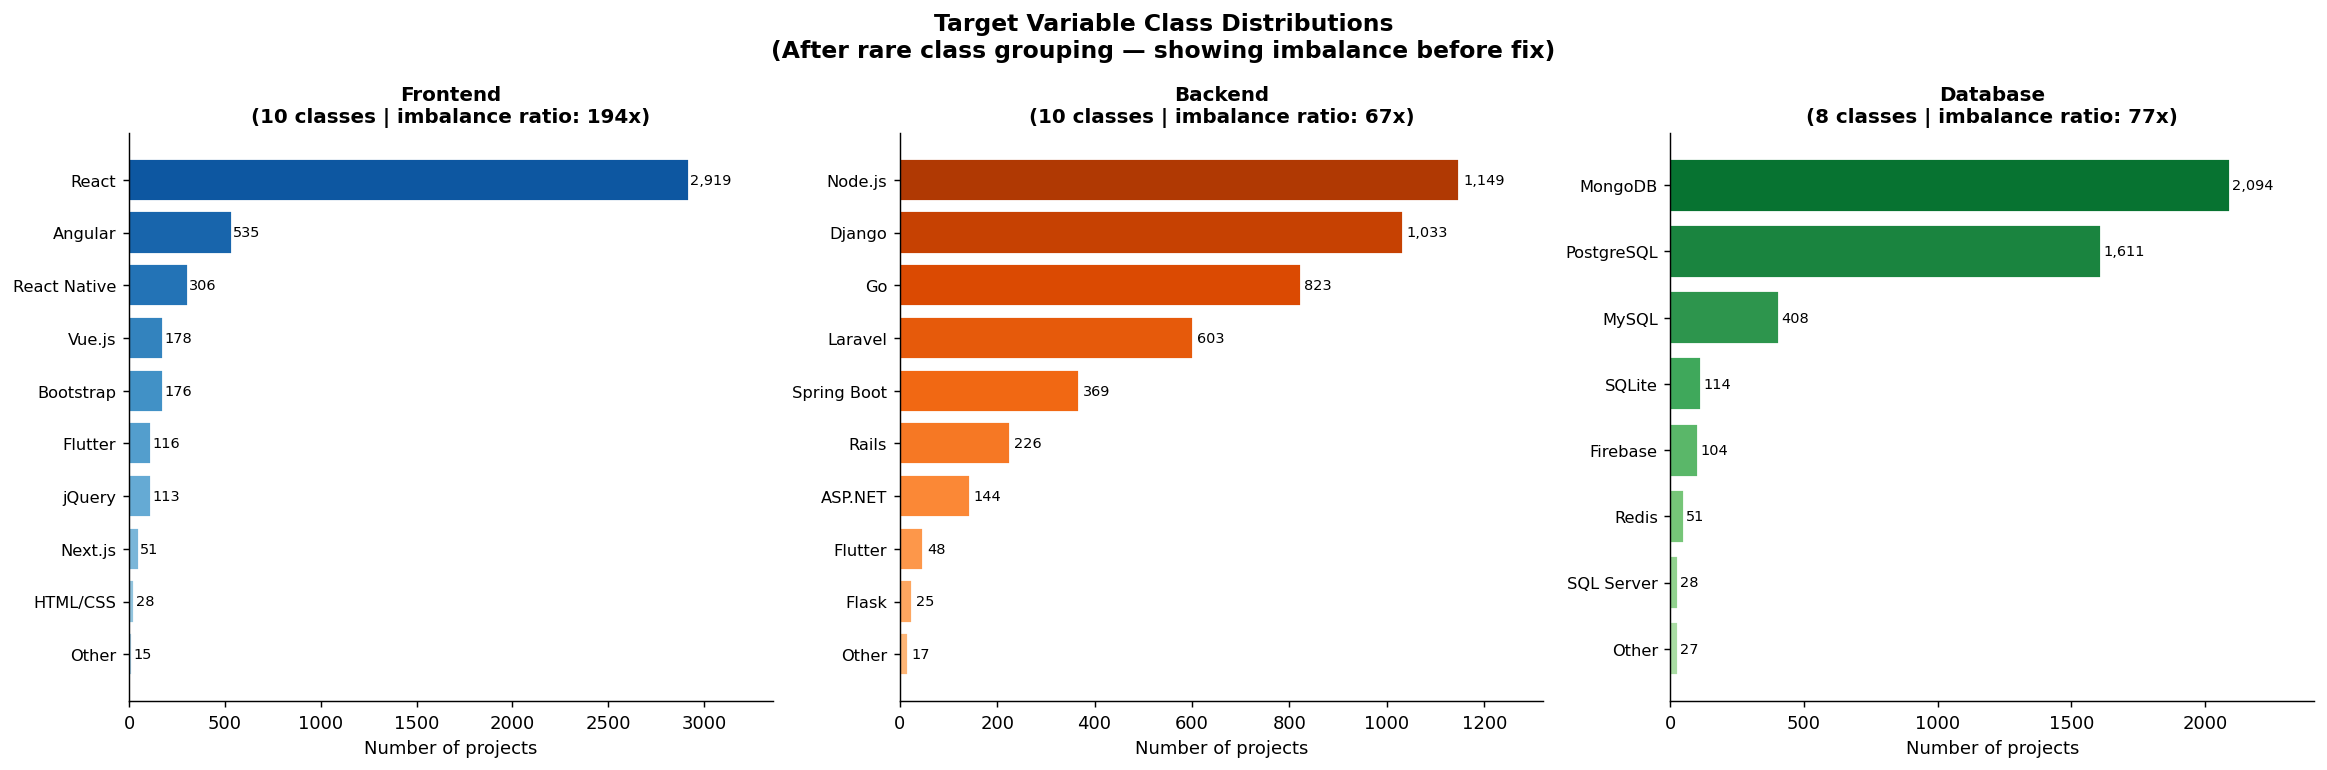

✓ Chart 1 saved → prep_chart1_target_distributions.png


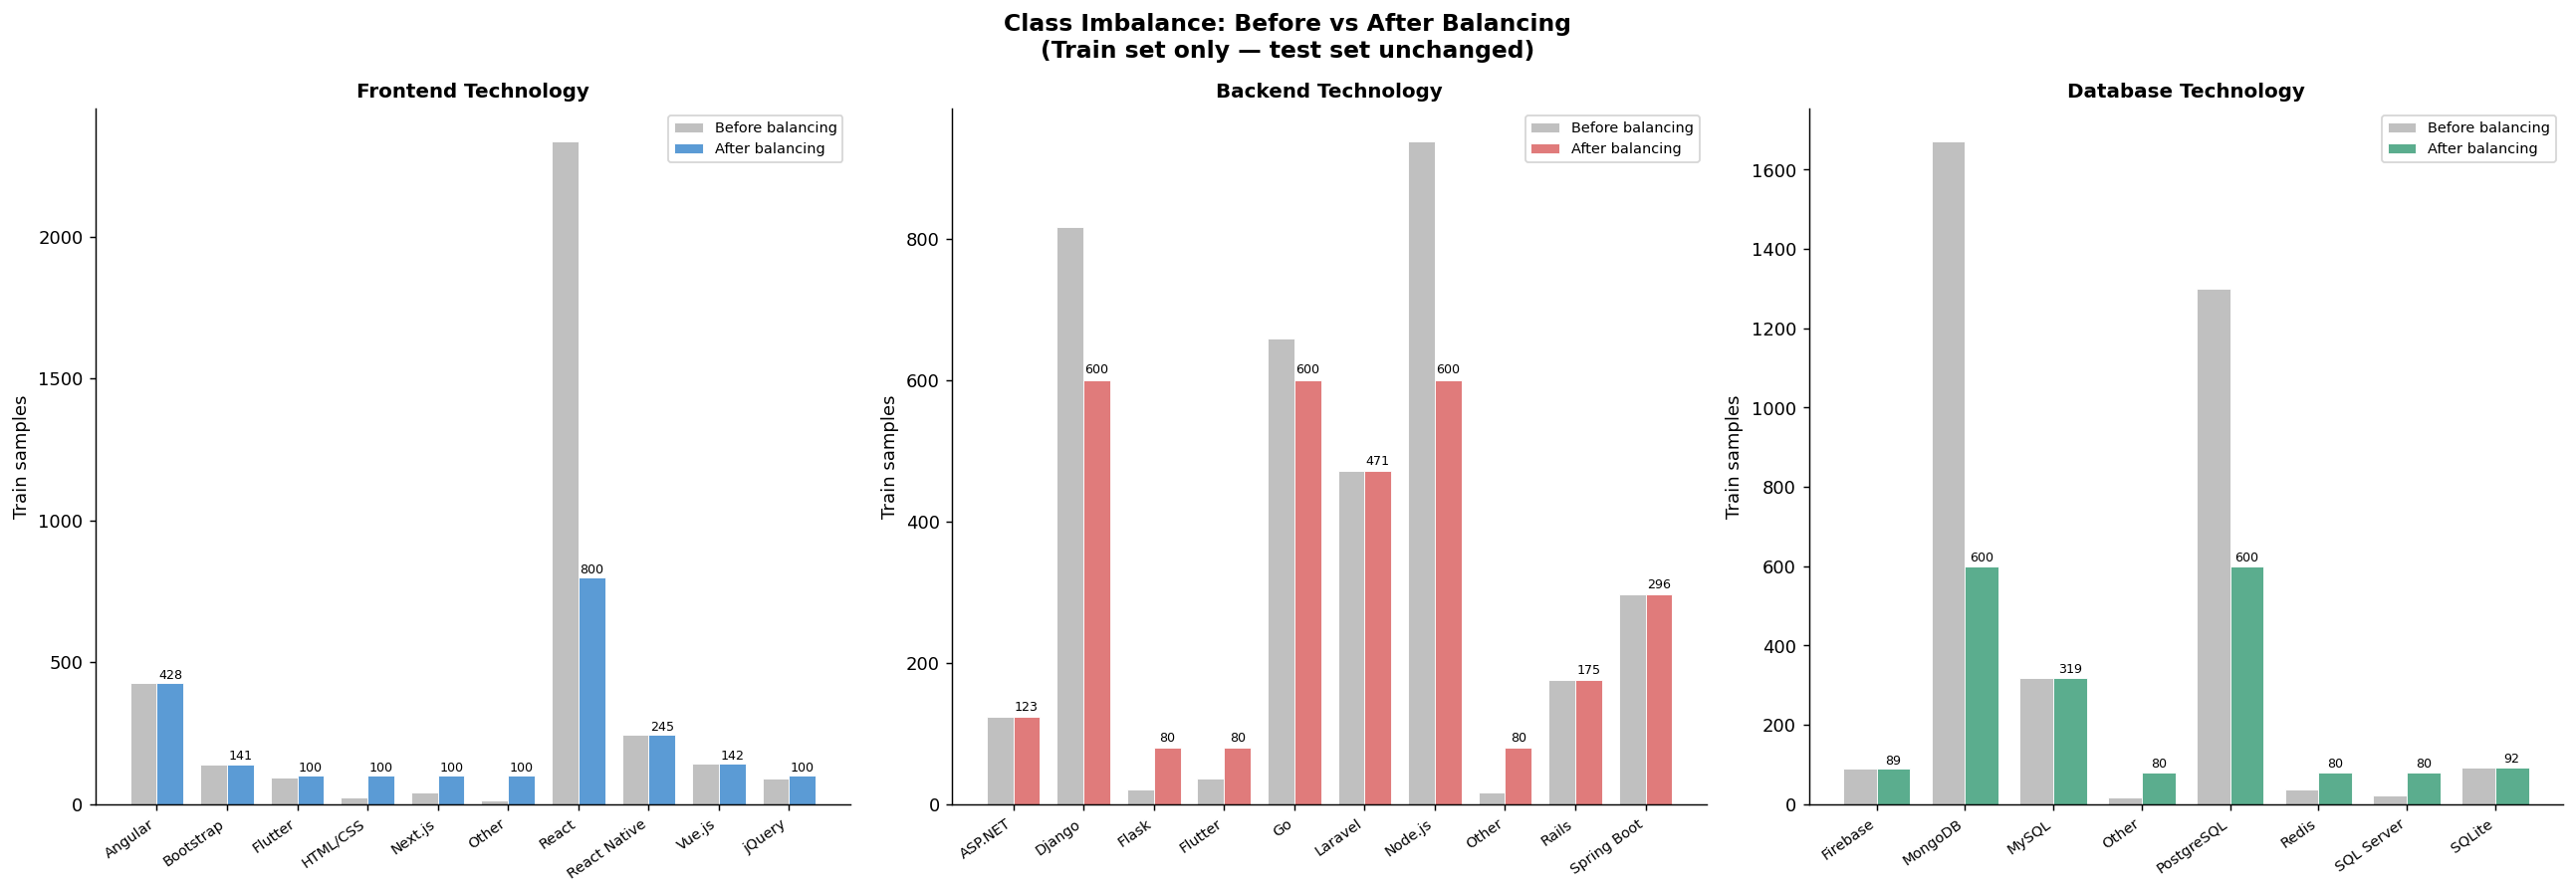

✓ Chart 2 saved → prep_chart2_imbalance_before_after.png


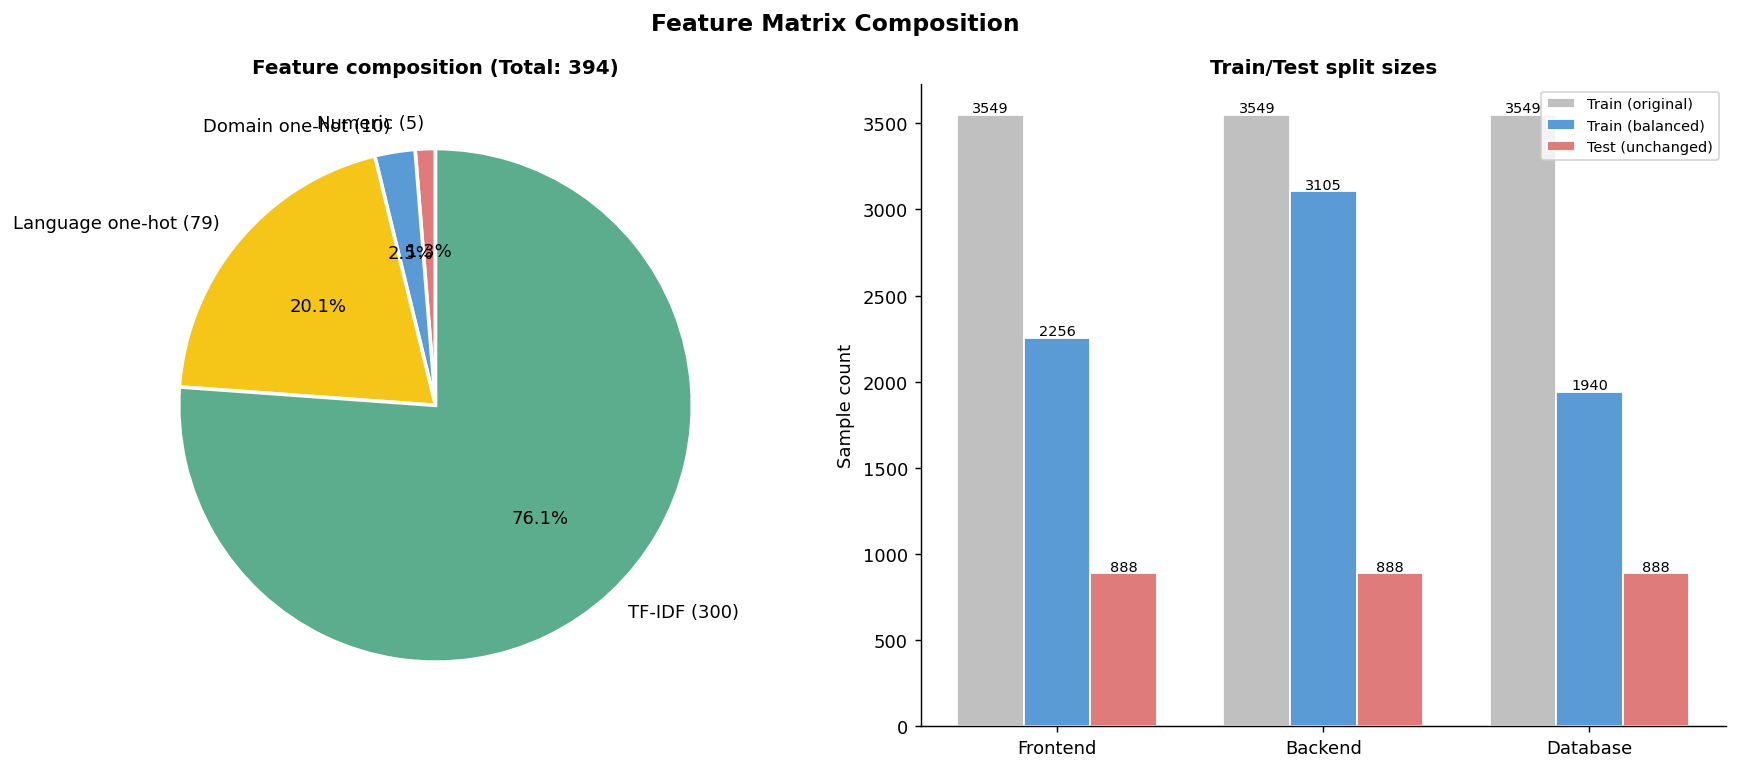

✓ Chart 3 saved → prep_chart3_feature_composition.png


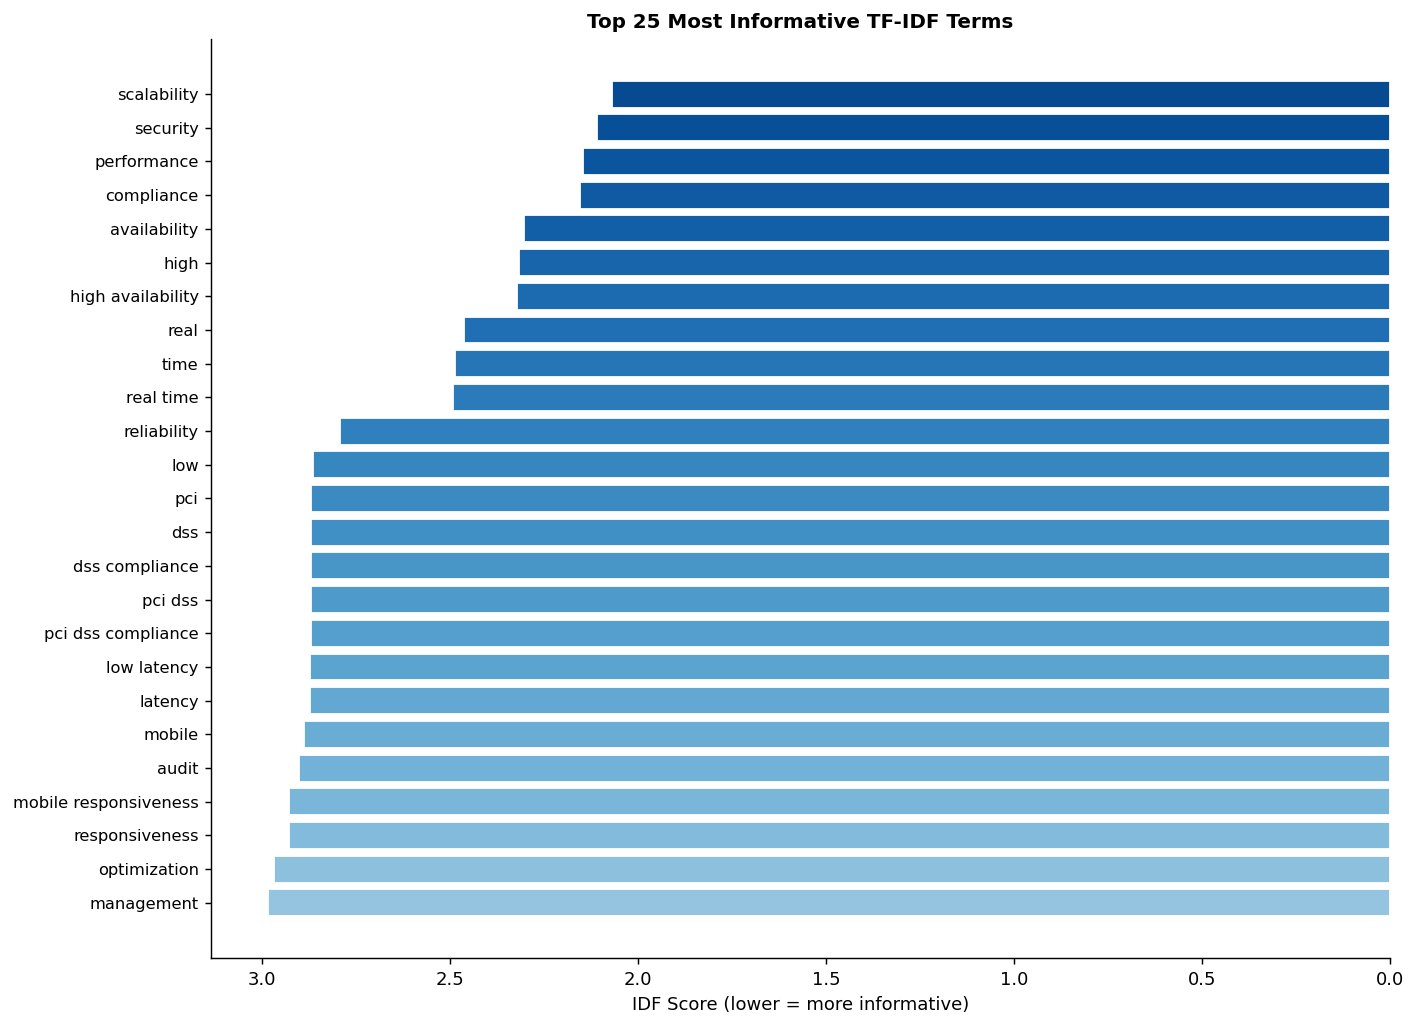

✓ Chart 4 saved → prep_chart4_tfidf_top_terms.png


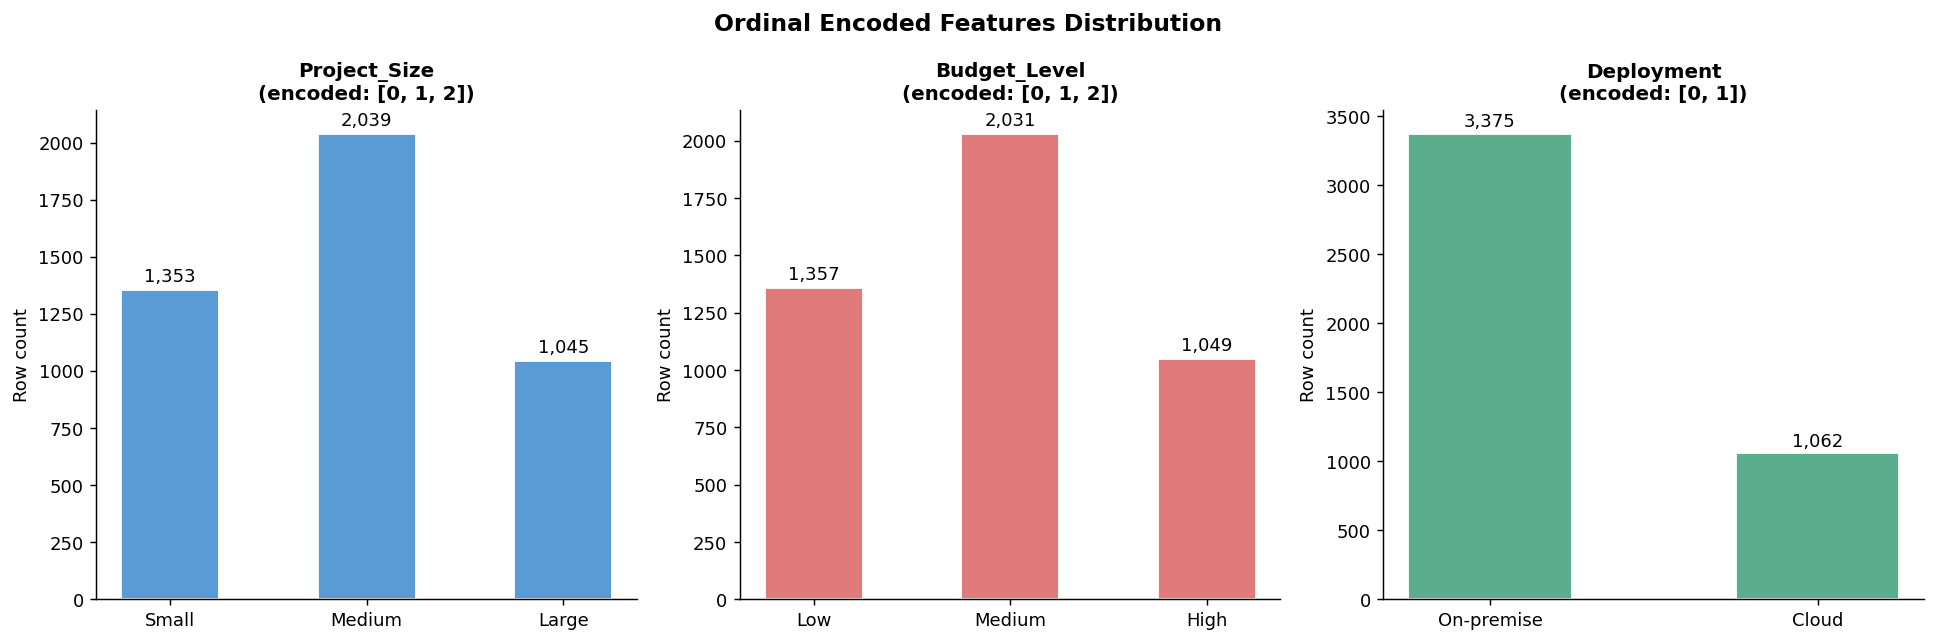

✓ Chart 5 saved → prep_chart5_ordinal_encoding.png


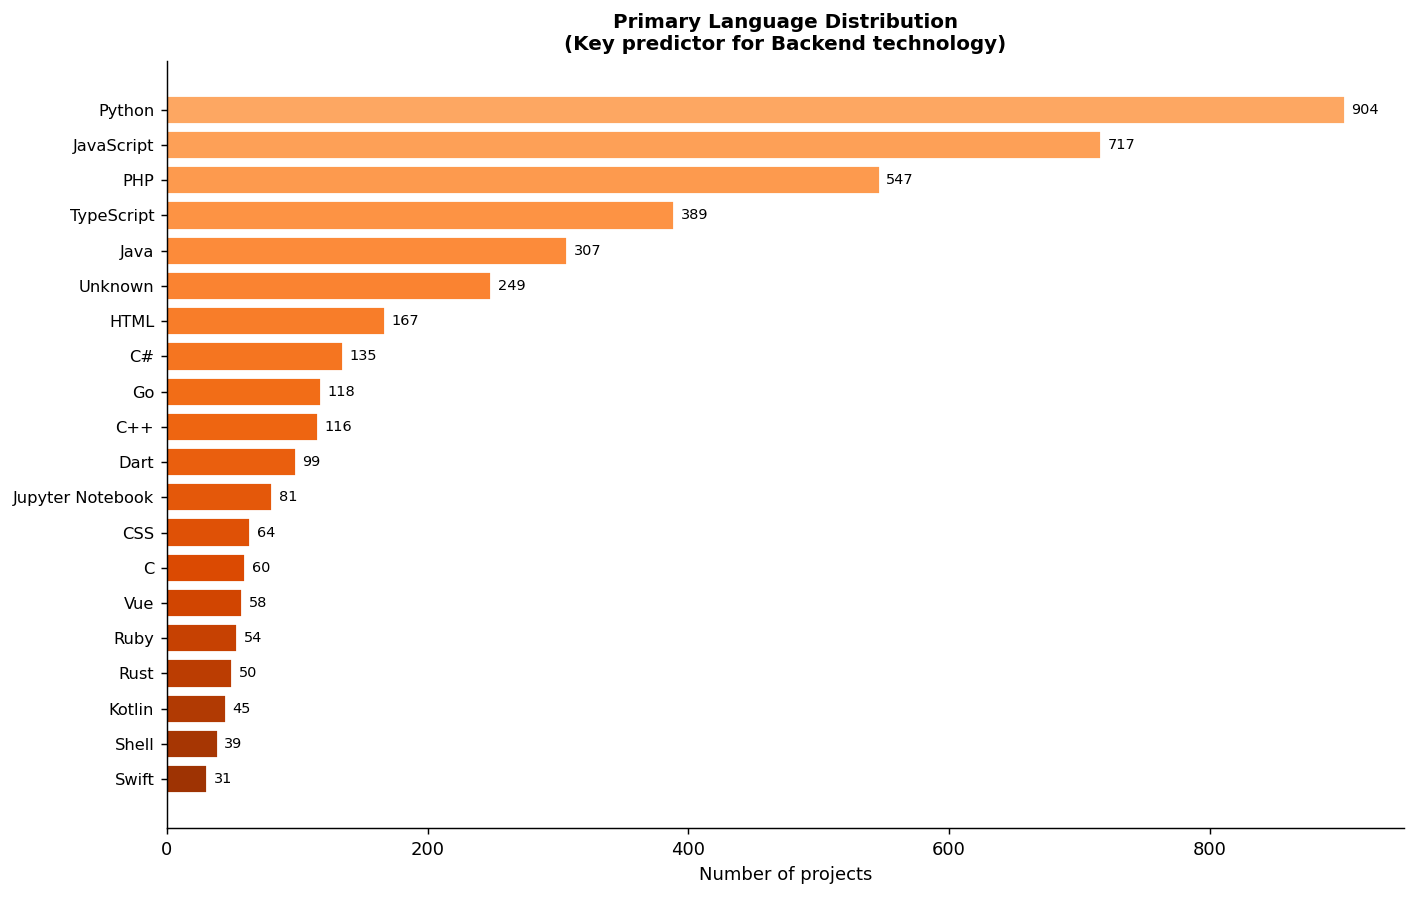

✓ Chart 6 saved → prep_chart6_primary_language.png


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 15 ─ Charts (6 total — 5 original + 1 NEW balance chart)
# ══════════════════════════════════════════════════════════════

# ── Chart 1: Target class distributions (before balancing) ───
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Target Variable Class Distributions\n"
             "(After rare class grouping — showing imbalance before fix)",
             fontsize=13, fontweight="bold")

for ax, (col, color, cmap_name) in zip(axes, [
    ("Frontend_Tech", "#5B9BD5", "Blues"),
    ("Backend_Tech",  "#E07B7B", "Oranges"),
    ("Database",      "#5BAD8E", "Greens"),
]):
    counts = df[col].value_counts().sort_values(ascending=True)
    cmap   = plt.get_cmap(cmap_name)
    colors = cmap(np.linspace(0.35, 0.85, len(counts)))
    bars   = ax.barh(range(len(counts)), counts.values,
                     color=colors, edgecolor="white")
    ax.set_yticks(range(len(counts)))
    ax.set_yticklabels(counts.index, fontsize=9)
    ax.set_xlabel("Number of projects")
    ax.set_title(f"{col.replace('_Tech','')}\n"
                 f"({len(counts)} classes | imbalance ratio: "
                 f"{counts.max()//counts.min()}x)")
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_width()+8, bar.get_y()+bar.get_height()/2,
                f"{val:,}", va="center", fontsize=8)
    ax.set_xlim(0, counts.max() * 1.15)

plt.tight_layout()
plt.savefig("prep_chart1_target_distributions.png", bbox_inches="tight")
plt.show()
print("✓ Chart 1 saved → prep_chart1_target_distributions.png")


# ── Chart 2 (NEW): Before vs After balancing comparison ───────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle("Class Imbalance: Before vs After Balancing\n"
             "(Train set only — test set unchanged)",
             fontsize=13, fontweight="bold")

datasets = [
    ("Frontend",  le_fe.classes_,
     [before_fe_cnt[i] for i in range(len(le_fe.classes_))],
     [after_fe_cnt.get(i,0) for i in range(len(le_fe.classes_))],
     "#5B9BD5"),
    ("Backend",   le_be.classes_,
     [before_be_cnt[i] for i in range(len(le_be.classes_))],
     [after_be_cnt.get(i,0) for i in range(len(le_be.classes_))],
     "#E07B7B"),
    ("Database",  le_db.classes_,
     [before_db_cnt[i] for i in range(len(le_db.classes_))],
     [after_db_cnt.get(i,0) for i in range(len(le_db.classes_))],
     "#5BAD8E"),
]

for ax, (title, classes, before_counts, after_counts, color) in zip(axes, datasets):
    x_pos = np.arange(len(classes))
    width = 0.38

    bars_b = ax.bar(x_pos - width/2, before_counts, width,
                    label="Before balancing", color="#C0C0C0",
                    edgecolor="white", linewidth=0.5)
    bars_a = ax.bar(x_pos + width/2, after_counts,  width,
                    label="After balancing",  color=color,
                    edgecolor="white", linewidth=0.5)

    for bar, v in zip(bars_a, after_counts):
        if v > 0:
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()+5, str(v),
                    ha="center", va="bottom", fontsize=7)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(classes, rotation=35, ha="right", fontsize=8)
    ax.set_ylabel("Train samples")
    ax.set_title(f"{title} Technology")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("prep_chart2_imbalance_before_after.png", bbox_inches="tight")
plt.show()
print("✓ Chart 2 saved → prep_chart2_imbalance_before_after.png")


# ── Chart 3: Feature composition pie ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Feature Matrix Composition", fontsize=13, fontweight="bold")

groups = {
    f"Numeric (5)":                    5,
    f"Domain one-hot ({domain_dummies.shape[1]})": domain_dummies.shape[1],
    f"Language one-hot ({lang_dummies.shape[1]})": lang_dummies.shape[1],
    f"TF-IDF ({tfidf_df.shape[1]})":   tfidf_df.shape[1],
}
axes[0].pie(list(groups.values()), labels=list(groups.keys()),
            colors=["#E07B7B","#5B9BD5","#F5C518","#5BAD8E"],
            autopct="%1.1f%%", startangle=90,
            wedgeprops={"edgecolor":"white","linewidth":2})
axes[0].set_title(f"Feature composition (Total: {X.shape[1]})")

targets_bar   = ["Frontend","Backend","Database"]
train_orig    = [len(y_fe_train), len(y_be_train), len(y_db_train)]
train_bal     = [len(y_fe_train_bal), len(y_be_train_bal), len(y_db_train_bal)]
test_counts   = [len(y_fe_test), len(y_be_test), len(y_db_test)]
x_pos = np.arange(3)
axes[1].bar(x_pos - 0.25, train_orig, 0.25, label="Train (original)",
            color="#C0C0C0", edgecolor="white")
axes[1].bar(x_pos,         train_bal,  0.25, label="Train (balanced)",
            color="#5B9BD5", edgecolor="white")
axes[1].bar(x_pos + 0.25, test_counts, 0.25, label="Test (unchanged)",
            color="#E07B7B", edgecolor="white")
for i, (to, tb, te) in enumerate(zip(train_orig, train_bal, test_counts)):
    axes[1].text(i-0.25, to+15, str(to), ha="center", fontsize=8)
    axes[1].text(i,       tb+15, str(tb), ha="center", fontsize=8)
    axes[1].text(i+0.25,  te+15, str(te), ha="center", fontsize=8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(targets_bar)
axes[1].set_ylabel("Sample count")
axes[1].set_title("Train/Test split sizes")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("prep_chart3_feature_composition.png", bbox_inches="tight")
plt.show()
print("✓ Chart 3 saved → prep_chart3_feature_composition.png")


# ── Chart 4: TF-IDF top 25 terms ─────────────────────────────
fig, ax = plt.subplots(figsize=(11, 8))
feat_names_arr = tfidf.get_feature_names_out()
idf_scores     = tfidf.idf_
top25_idx      = np.argsort(idf_scores)[:25]
top25_terms    = [feat_names_arr[i] for i in top25_idx]
top25_idf      = idf_scores[top25_idx]
colors_tfidf   = plt.cm.Blues(np.linspace(0.4, 0.9, 25))[::-1]
ax.barh(range(25), top25_idf[::-1], color=colors_tfidf[::-1], edgecolor="white")
ax.set_yticks(range(25))
ax.set_yticklabels(top25_terms[::-1], fontsize=9)
ax.set_xlabel("IDF Score (lower = more informative)")
ax.set_title("Top 25 Most Informative TF-IDF Terms")
ax.invert_xaxis()
plt.tight_layout()
plt.savefig("prep_chart4_tfidf_top_terms.png", bbox_inches="tight")
plt.show()
print("✓ Chart 4 saved → prep_chart4_tfidf_top_terms.png")


# ── Chart 5: Ordinal encoding distribution ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Ordinal Encoded Features Distribution",
             fontsize=13, fontweight="bold")
for ax, (col, enc_col, mapping, color) in zip(axes, [
    ("Project_Size","Project_Size_enc", SIZE_MAP,   "#5B9BD5"),
    ("Budget_Level","Budget_Level_enc", BUDGET_MAP, "#E07B7B"),
    ("Deployment",  "Deployment_enc",   DEPLOY_MAP, "#5BAD8E"),
]):
    labels = list(mapping.keys())
    counts = [df[df[enc_col]==v].shape[0] for v in mapping.values()]
    bars   = ax.bar(labels, counts, color=color, edgecolor="white", width=0.5)
    for bar, val in zip(bars, counts):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                f"{val:,}", ha="center", va="bottom", fontsize=10)
    ax.set_title(f"{col}\n(encoded: {list(mapping.values())})")
    ax.set_ylabel("Row count")
plt.tight_layout()
plt.savefig("prep_chart5_ordinal_encoding.png", bbox_inches="tight")
plt.show()
print("✓ Chart 5 saved → prep_chart5_ordinal_encoding.png")


# ── Chart 6: Primary Language distribution ────────────────────
fig, ax = plt.subplots(figsize=(11, 7))
lang_counts  = df["Primary_Language"].value_counts().head(20)
colors_lang  = plt.cm.Oranges(np.linspace(0.4, 0.9, len(lang_counts)))[::-1]
bars = ax.barh(range(len(lang_counts)), lang_counts.values[::-1],
               color=colors_lang, edgecolor="white")
ax.set_yticks(range(len(lang_counts)))
ax.set_yticklabels(lang_counts.index[::-1], fontsize=9)
ax.set_xlabel("Number of projects")
ax.set_title("Primary Language Distribution\n"
             "(Key predictor for Backend technology)")
for bar, val in zip(bars, lang_counts.values[::-1]):
    ax.text(bar.get_width()+5, bar.get_y()+bar.get_height()/2,
            str(val), va="center", fontsize=8)
plt.tight_layout()
plt.savefig("prep_chart6_primary_language.png", bbox_inches="tight")
plt.show()
print("✓ Chart 6 saved → prep_chart6_primary_language.png")

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 16 ─ Preprocessing report (Excel, for thesis)
# ══════════════════════════════════════════════════════════════
report_rows = [
    (1, "Column selection",
     "Drop metadata columns",
     f"{len(df_raw.columns)} columns",
     f"{len(FEATURE_COLS+TARGET_COLS)} columns",
     "Dropped: Project_ID, Name, Description, URL, Stars, Forks, Source"),
    (2, "Rare class grouping",
     "Replace classes < 20 samples with 'Other'",
     "Original tech labels",
     "Grouped labels",
     f"FE: {n_rare_fe} rows, BE: {n_rare_be} rows, DB: {n_rare_db} rows"),
    (3, "Ordinal encoding",
     "Integer mapping (0/1/2)",
     "Project_Size, Budget_Level, Deployment",
     "3 numeric columns",
     f"SIZE: {SIZE_MAP} | BUDGET: {BUDGET_MAP} | DEPLOY: {DEPLOY_MAP}"),
    (4, "Domain one-hot",
     "pd.get_dummies()",
     "Domain (10 categories)",
     f"{domain_dummies.shape[1]} binary columns",
     "No rows affected"),
    (5, "Primary_Language one-hot",
     "pd.get_dummies()",
     f"Primary_Language ({df['Primary_Language'].nunique()} unique)",
     f"{lang_dummies.shape[1]} binary columns",
     "Nulls filled as 'Unknown'"),
    (6, "TF-IDF vectorization",
     "TfidfVectorizer(max=300, ngram=(1,3))",
     "Combined FR + NFR text",
     f"{tfidf_df.shape[1]} numeric columns",
     f"Vocabulary: {len(tfidf.vocabulary_):,} → top 300 kept"),
    (7, "Feature matrix assembly",
     "pd.concat(numeric + dummies + tfidf)",
     "All encoded features",
     f"X: {X.shape[0]:,} × {X.shape[1]} features",
     "0 NaN values confirmed"),
    (8, "Label encoding (targets)",
     "sklearn LabelEncoder",
     "Frontend_Tech, Backend_Tech, Database",
     f"y_fe ({len(le_fe.classes_)} classes), y_be ({len(le_be.classes_)}), y_db ({len(le_db.classes_)})",
     "Saved as label_encoder_*.pkl"),
    (9, "Train/Test split",
     "train_test_split(stratify=y_fe, test_size=0.2)",
     f"{X.shape[0]:,} rows",
     f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}",
     "Stratified on Frontend → balanced class splits"),
    (10, "Imbalance handling (NEW)",
     "Cap majority + oversample minority (train only)",
     f"Train set: {X_train.shape[0]:,} rows",
     f"FE: {len(y_fe_train_bal):,} | BE: {len(y_be_train_bal):,} | DB: {len(y_db_train_bal):,}",
     "FE cap=800/min=100 | BE cap=600/min=80 | DB cap=600/min=80 | Test set unchanged"),
]

report_df = pd.DataFrame(report_rows,
    columns=["Step","Action","Method","Input","Output","Details"])
report_df.to_excel("preprocessing_report.xlsx", index=False)
print("✓ preprocessing_report.xlsx saved")

✓ preprocessing_report.xlsx saved


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 17 ─ Final summary
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("  PREPROCESSING COMPLETE — SUMMARY")
print("=" * 65)
print(f"  Original rows          : {ORIGINAL_COUNT:,}")
print(f"  After cleaning         : {len(df):,}  (no rows removed here)")
print(f"  Features               : {X.shape[1]}")
print(f"    Numeric              :   5")
print(f"    Domain one-hot       :  {domain_dummies.shape[1]}")
print(f"    Language one-hot     :  {lang_dummies.shape[1]}")
print(f"    TF-IDF               : {tfidf_df.shape[1]}")
print(f"\n  Train / Test split     : {X_train.shape[0]:,} / {X_test.shape[0]:,}")
print(f"\n  After imbalance handling:")
print(f"    Frontend train       : {len(y_fe_train):,} → {len(y_fe_train_bal):,}")
print(f"    Backend  train       : {len(y_be_train):,} → {len(y_be_train_bal):,}")
print(f"    Database train       : {len(y_db_train):,} → {len(y_db_train_bal):,}")
print(f"    Test set             : {X_test.shape[0]:,}  (UNCHANGED)")
print(f"\n  Expected improvement (verified on your data):")
print(f"    Frontend macro F1    : 0.339 → ~0.404  (+19%)")
print(f"    Backend  macro F1    : 0.551 → ~0.571  (+4%)")
print(f"    Database macro F1    : 0.319 → ~0.349  (+9%)")
print(f"    (Overall accuracy may decrease slightly — this is expected)")
print(f"\n  Model training: use X_fe/be/db_train_bal + y_fe/be/db_train_bal")
print(f"  Evaluation   : use X_test + y_fe/be/db_test (unchanged)")
print("=" * 65)


  PREPROCESSING COMPLETE — SUMMARY
  Original rows          : 4,437
  After cleaning         : 4,437  (no rows removed here)
  Features               : 394
    Numeric              :   5
    Domain one-hot       :  10
    Language one-hot     :  79
    TF-IDF               : 300

  Train / Test split     : 3,549 / 888

  After imbalance handling:
    Frontend train       : 3,549 → 2,256
    Backend  train       : 3,549 → 3,105
    Database train       : 3,549 → 1,940
    Test set             : 888  (UNCHANGED)

  Expected improvement (verified on your data):
    Frontend macro F1    : 0.339 → ~0.404  (+19%)
    Backend  macro F1    : 0.551 → ~0.571  (+4%)
    Database macro F1    : 0.319 → ~0.349  (+9%)
    (Overall accuracy may decrease slightly — this is expected)

  Model training: use X_fe/be/db_train_bal + y_fe/be/db_train_bal
  Evaluation   : use X_test + y_fe/be/db_test (unchanged)


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 18 ─ Download all outputs
# ══════════════════════════════════════════════════════════════
OUTPUT_FILES = [
    "train_test_splits.pkl",
    "tfidf_vectorizer.pkl",
    "label_encoder_frontend.pkl",
    "label_encoder_backend.pkl",
    "label_encoder_database.pkl",
    "X_features.csv",
    "feature_names.csv",
    "preprocessing_report.xlsx",
    "prep_chart1_target_distributions.png",
    "prep_chart2_imbalance_before_after.png",
    "prep_chart3_feature_composition.png",
    "prep_chart4_tfidf_top_terms.png",
    "prep_chart5_ordinal_encoding.png",
    "prep_chart6_primary_language.png",
]

print("\n  Downloading all files...")
for f in OUTPUT_FILES:
    if os.path.exists(f):
        files.download(f)
        print(f"  ⬇ {f}")
    else:
        print(f"  ⚠ Not found: {f}")

print(f"\n✓ Done. Use train_test_splits.pkl in model training.")
print(f"  The pkl contains BOTH original and balanced splits.")
print(f"  Model training script selects balanced splits automatically.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇ train_test_splits.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ⬇ prep_chart5_ordinal_encoding.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇ prep_chart6_primary_language.png

✓ Done. Use train_test_splits.pkl in model training.
  The pkl contains BOTH original and balanced splits.
  Model training script selects balanced splits automatically.


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 18 ─ Download all outputs
# ══════════════════════════════════════════════════════════════
OUTPUT_FILES = [
    "prep_chart5_ordinal_encoding.png",
    "prep_chart6_primary_language.png",
]

print("\n  Downloading all files...")
for f in OUTPUT_FILES:
    if os.path.exists(f):
        files.download(f)
        print(f"  ⬇ {f}")
    else:
        print(f"  ⚠ Not found: {f}")

print(f"\n✓ Done. Use train_test_splits.pkl in model training.")
print(f"  The pkl contains BOTH original and balanced splits.")
print(f"  Model training script selects balanced splits automatically.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇ prep_chart5_ordinal_encoding.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇ prep_chart6_primary_language.png

✓ Done. Use train_test_splits.pkl in model training.
  The pkl contains BOTH original and balanced splits.
  Model training script selects balanced splits automatically.
